# 🛠️ Feature Engineering

Preprocessing (topic 03) makes data *usable*. Feature engineering makes it *predictive* — creating, transforming, and selecting the inputs that actually help a model learn. It's widely considered the single highest-leverage skill in classical ML: a well-engineered feature set often beats a fancier algorithm on mediocre features.

📖 Full mathematical explanation (log/Box-Cox transforms, polynomial expansion, selection criteria): [README.md](README.md)


## 1. Setup — A Dataset Worth Engineering

We simulate an e-commerce-style dataset with a date column (rich for decomposition), a right-skewed monetary feature (needs a transform), and several raw numeric features (candidates for interaction terms and selection).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")
np.random.seed(42)

n = 300
dates = pd.date_range("2024-01-01", periods=n, freq="D")
df = pd.DataFrame({
    "order_date": np.random.choice(dates, n),
    "unit_price": np.random.exponential(scale=25, size=n) + 5,   # right-skewed, like real price data
    "quantity": np.random.randint(1, 10, n),
    "customer_age": np.random.normal(35, 12, n).clip(18, 75),
    "delivery_days": np.random.poisson(4, n) + 1,
})
df["total_spend"] = df["unit_price"] * df["quantity"] * np.random.normal(1, 0.05, n)

df.head()


,order_date,unit_price,quantity,customer_age,delivery_days,total_spend
0,2024-04-12,32.803346,3,25.441964,4,90.907722
1,2024-09-27,16.104373,7,42.929303,9,105.101231
2,2024-04-16,12.331227,6,40.703826,7,73.021993
3,2024-03-12,13.749244,2,50.826063,3,25.727893
4,2024-07-07,14.735516,6,32.479800,4,83.080589


## 2. Feature Creation — Date Decomposition

A single `datetime` column is low-value on its own for most models, but decomposes into several high-value features: cyclical patterns (month, day-of-week) and simple flags (is_weekend) that a raw timestamp hides.


In [2]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["order_month"] = df["order_date"].dt.month
df["order_dayofweek"] = df["order_date"].dt.dayofweek       # 0=Monday ... 6=Sunday
df["is_weekend"] = df["order_dayofweek"].isin([5, 6]).astype(int)

print(df[["order_date", "order_month", "order_dayofweek", "is_weekend"]].head())
print("\nWeekend order share:", df['is_weekend'].mean().round(3))


  order_date  order_month  order_dayofweek  is_weekend
0 2024-04-12            4                4           0
1 2024-09-27            9                4           0
2 2024-04-16            4                1           0
3 2024-03-12            3                1           0
4 2024-07-07            7                6           1

Weekend order share: 0.28


## 3. Feature Creation — Ratios & Interaction Terms

Domain-derived ratios often carry more signal than either raw component alone, and **interaction terms** capture effects that only appear when two features combine (e.g., older customers buying in bulk might behave differently than young bulk-buyers).

⚠️ **Leakage warning:** a ratio feature must only combine *input* columns, never the target. Dividing the target by something and feeding that back in as a feature (e.g. `total_spend / delivery_days` to predict `total_spend`) is **target leakage** — it smuggles the answer into the inputs and makes a model look artificially accurate. The ratio below (`unit_price / delivery_days`) is built only from other input features, so it stays legitimate.


In [3]:
# Ratio feature: ties two raw INPUT columns (never the target) into one more meaningful signal
df["price_per_delivery_day"] = df["unit_price"] / df["delivery_days"]

# Manual interaction term: captures a combined effect neither feature alone represents
df["age_x_quantity"] = df["customer_age"] * df["quantity"]

# PolynomialFeatures: generates ALL interaction + squared terms automatically for a feature subset
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
poly_input = df[["unit_price", "quantity"]]
poly_features = poly.fit_transform(poly_input)
poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(["unit_price", "quantity"]))
poly_df.head()


,unit_price,quantity,unit_price^2,unit_price quantity,quantity^2
0,32.803346,3.0,1076.059517,98.410038,9.0
1,16.104373,7.0,259.350838,112.730613,49.0
2,12.331227,6.0,152.059154,73.987361,36.0
3,13.749244,2.0,189.041699,27.498487,4.0
4,14.735516,6.0,217.135445,88.413099,36.0


## 4. Feature Transformation — Fixing Skew

`unit_price` was generated from an exponential distribution — heavily right-skewed. Many algorithms (especially linear ones) assume roughly symmetric, normally-shaped features. Two standard fixes, compared below:

- **Log transform** — simple, fast, only valid for strictly positive values
- **Box-Cox / Yeo-Johnson (`PowerTransformer`)** — finds the *best* power transform automatically, Yeo-Johnson also handles zero/negative values


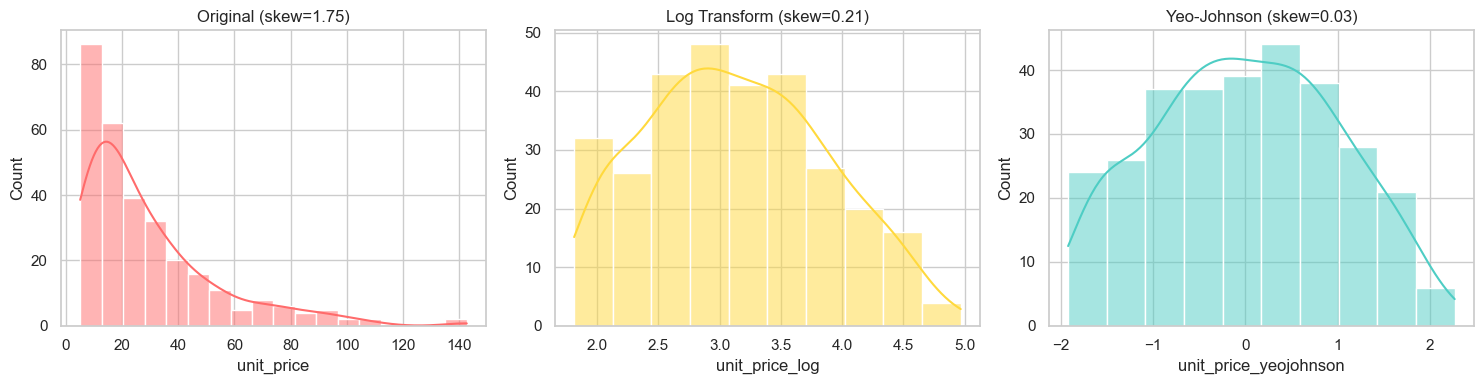

In [4]:
df["unit_price_log"] = np.log1p(df["unit_price"])   # log1p = log(1+x), safe even if x is ever 0

pt = PowerTransformer(method="yeo-johnson")
df["unit_price_yeojohnson"] = pt.fit_transform(df[["unit_price"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["unit_price"], kde=True, ax=axes[0], color="#ff6b6b")
axes[0].set_title(f"Original (skew={df['unit_price'].skew():.2f})")

sns.histplot(df["unit_price_log"], kde=True, ax=axes[1], color="#ffd93d")
axes[1].set_title(f"Log Transform (skew={df['unit_price_log'].skew():.2f})")

sns.histplot(df["unit_price_yeojohnson"], kde=True, ax=axes[2], color="#4ecdc4")
axes[2].set_title(f"Yeo-Johnson (skew={df['unit_price_yeojohnson'].skew():.2f})")

plt.tight_layout()
plt.show()


## 5. Feature Transformation — Binning (Discretization)

Binning converts a continuous variable into ordered categories — useful when a model benefits from a simpler, non-linear-friendly grouping, or for readability in reports (e.g., age brackets instead of raw age).


In [5]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[18, 25, 35, 50, 75],
    labels=["18-25", "26-35", "36-50", "51-75"]
)
print(df["age_group"].value_counts().sort_index())


age_group
18-25     34
26-35     90
36-50    114
51-75     40
Name: count, dtype: int64


## 6. Feature Selection — Filter Methods

Filter methods score each feature independently of any model, using a statistical criterion:

- **Variance Threshold** — drops near-constant features (they carry almost no information, regardless of relationship to the target)
- **Correlation filter** — drops one of any pair of features that are near-duplicates of each other (redundant, and destabilizing for linear models — see topic 02's heatmap discussion)
- **Mutual Information** — measures how much knowing a feature reduces uncertainty about the target, capturing non-linear relationships that Pearson correlation misses


In [6]:
numeric_features = ["unit_price", "quantity", "customer_age", "delivery_days", "age_x_quantity", "price_per_delivery_day"]
X = df[numeric_features]
y = df["total_spend"]

# Variance Threshold: flag near-constant columns (none expected here, but this is the mechanism)
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X)
print("Features kept by variance threshold:", list(X.columns[var_selector.get_support()]))

# Correlation filter: find highly correlated feature pairs (candidates for dropping one)
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper_triangle.columns for row in upper_triangle.index
                    if upper_triangle.loc[row, col] > 0.85]
print("Highly correlated pairs (|r| > 0.85):", high_corr_pairs)

# Mutual information: non-linear relationship strength with the target
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("\nMutual information with total_spend:\n", mi_series)


Features kept by variance threshold: ['unit_price', 'quantity', 'customer_age', 'delivery_days', 'age_x_quantity', 'price_per_delivery_day']
Highly correlated pairs (|r| > 0.85): []

Mutual information with total_spend:
 unit_price                0.642430
quantity                  0.340066
price_per_delivery_day    0.333712
age_x_quantity            0.258955
delivery_days             0.014244
customer_age              0.000000
dtype: float64


## 7. Feature Selection — Embedded Method (Model-Based Importance)

Embedded methods let a model itself score feature usefulness *while* training. A quick Random Forest's built-in importance (based on how much each feature reduces prediction error across all trees) is a fast, model-aware selection signal — more on how tree-based importance is computed in the Classical ML → Random Forest notebook.


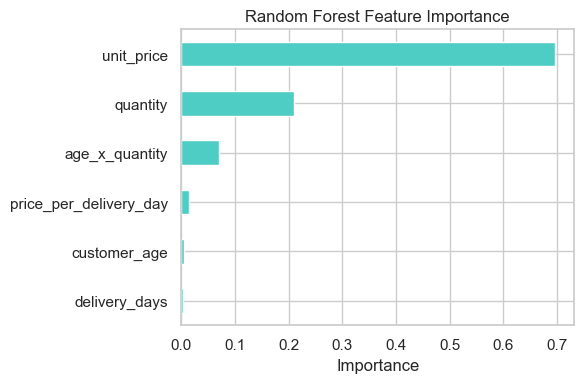

unit_price                0.696591
quantity                  0.210251
age_x_quantity            0.070608
price_per_delivery_day    0.013425
customer_age              0.005241
delivery_days             0.003885
dtype: float64


In [7]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
importance.plot(kind="barh", ax=ax, color="#4ecdc4")
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance)


## ✅ Key Takeaways

- Feature creation (date decomposition, ratios, interaction terms) often unlocks more predictive power than switching algorithms — always exhaust domain-driven feature ideas first.
- Log/Yeo-Johnson transforms reduce skew, directly helping linear models' assumptions; check the `.skew()` value before and after, don't just eyeball it.
- Filter methods (variance, correlation, mutual information) are fast, model-agnostic first passes; embedded methods (model feature importance) give a second, model-aware opinion — using both together is more reliable than either alone.
- Compare the mutual information and Random Forest importance scores above for `age_x_quantity` and `price_per_delivery_day` (both hand-built) against the raw columns — engineered features routinely rival or beat raw ones, which is exactly why this step isn't optional.
- **Always audit a new feature for target leakage** before trusting its importance score — a feature that's algebraically derived from the target (like the mistake caught and fixed while building this notebook) will look artificially important without being real signal.
- This topic sets up every Classical ML notebook that follows: the feature matrix $X$ they all `fit()` on is the product of exactly this pipeline.

**Next up:** [05_Math_Refresher](../05_Math_Refresher/) — the linear algebra, probability, and statistics underpinning every algorithm ahead.
